In [45]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT / "src"))

from compare.plots import plot_lines, plot_eer, plot_f1

df = pd.read_parquet(ROOT / "results" / "sweep.parquet")

# Slide 1: GMM-only comparison

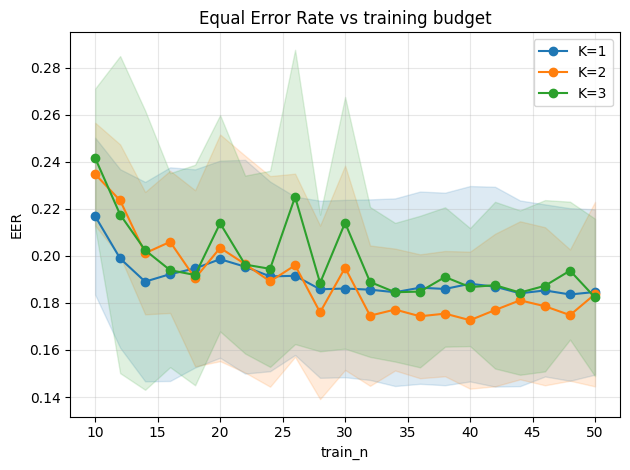

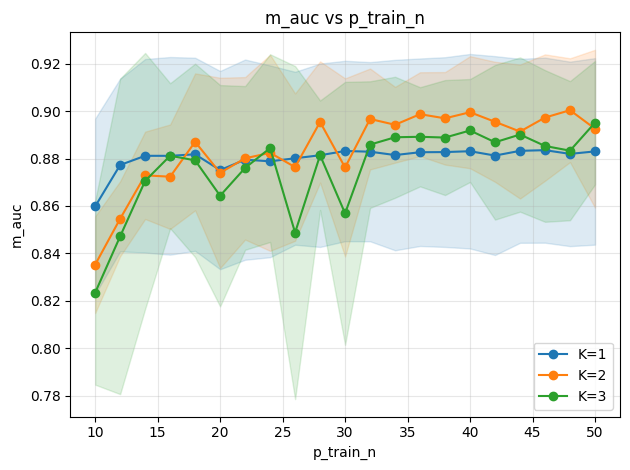

In [46]:
gmm_lines = [
    ("K=1", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
]

plot_eer(df, lines=gmm_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=gmm_lines)

# Slide 2: Best GMMs vs AE (full epochs) vs kNN

In [ ]:
compare_lines = [
    ("AE ep=100",    {"p_adapter": "AutoencoderAdapter", "p_epochs": 100}),
    ("SmallAE L=8 ep=100", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("GMM K=2",      {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
]

plot_eer(df, lines=compare_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=compare_lines)
plot_f1(df, lines=compare_lines)

# Slide 3: Training MACs comparison

In [ ]:
mac_lines = [
    ("AE ep=25",     {"p_adapter": "AutoencoderAdapter", "p_epochs": 25}),
    ("SmallAE L=4 ep=25",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 25}),
    ("SmallAE L=8 ep=25",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 25}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
]

for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in mac_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_macs", "m_eer")
        ax.plot(agg["m_training_macs"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Training MACs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training MACs (dim={dim})")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 4: MAC-fair comparison (low-epoch AE/LinAE vs GMM)

The linear AE has fewer parameters, so at the same epoch count its MAC cost is lower than the full AE. Compare lowest-epoch configs against GMM.

In [ ]:
fair_lines = [
    ("AE ep=25",     {"p_adapter": "AutoencoderAdapter", "p_epochs": 25}),
    ("AE ep=50",     {"p_adapter": "AutoencoderAdapter", "p_epochs": 50}),
    ("SmallAE L=4 ep=25",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 25}),
    ("SmallAE L=8 ep=25",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 25}),
    ("GMM K=1",      {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",      {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
]

plot_eer(df, lines=fair_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=fair_lines)

# Slide 5: Training MACs (low-epoch AE vs GMM)

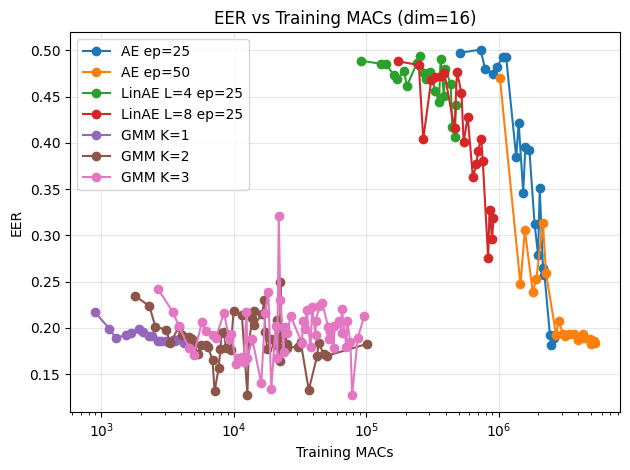

In [50]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_macs", "m_eer")
        ax.plot(agg["m_training_macs"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Training MACs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training MACs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 6: EER variance across target words

In [ ]:
target_lines = [
    ("GMM K=1", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("AE ep=100", {"p_adapter": "AutoencoderAdapter", "p_epochs": 100}),
    ("SmallAE L=8", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("kNN k=1",   {"p_adapter": "KNNAdapter", "p_k": 1}),
]

# EER per target word at fixed train_n — shows which words are harder to enroll
fixed_train_n = 50
sub = df[df["p_train_n"] == fixed_train_n]

fig, ax = plt.subplots(figsize=(10, 4))
from compare.plots import _filter
words = sorted(df["p_target_class"].unique())
x = range(len(words))
width = 0.8 / len(target_lines)
for i, (label, where) in enumerate(target_lines):
    means = [_filter(sub, where).groupby("p_target_class")["m_eer"].mean().get(w, float("nan")) for w in words]
    offset = (i - len(target_lines) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], means, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(words, rotation=30, ha="right")
ax.set_ylabel("EER")
ax.set_title(f"EER by target word (train_n={fixed_train_n})")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 7: Pareto frontier — iso-MAC comparison

In [ ]:
from compare.plots import plot_pareto

pareto_lines = [
    ("AE",      {"p_adapter": "AutoencoderAdapter"}),
    ("SmallAE", {"p_adapter": "SmallAEAdapter"}),
    ("GMM",     {"p_adapter": "GMMAdapter"}),
    ("kNN",     {"p_adapter": "KNNAdapter"}),
]

plot_pareto(df, lines=pareto_lines)
plt.show()

# Slide 8: AE training convergence

In [ ]:
from compare.plots import plot_loss_curves, plot_loss_vs_eer

# Loss curves: is training still improving at the last epoch?
# Each checkpoint is at 20%, 40%, 60%, 80%, 100% of training.
# A line still dropping at x=1.0 means the adapter needs more epochs.
loss_lines = [
    ("AE ep=25",            {"p_adapter": "AutoencoderAdapter", "p_epochs": 25}),
    ("AE ep=50",            {"p_adapter": "AutoencoderAdapter", "p_epochs": 50}),
    ("AE ep=100",           {"p_adapter": "AutoencoderAdapter", "p_epochs": 100}),
    ("SmallAE L=4 ep=25",   {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 25}),
    ("SmallAE L=4 ep=100",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 100}),
    ("SmallAE L=8 ep=25",   {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 25}),
    ("SmallAE L=8 ep=100",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
]

plot_loss_curves(df, lines=loss_lines)

# Does lower reconstruction loss actually translate to better EER?
plot_loss_vs_eer(df, lines=[
    ("AE",      {"p_adapter": "AutoencoderAdapter"}),
    ("SmallAE", {"p_adapter": "SmallAEAdapter"}),
])
plt.show()